# Nate Heller - Machine Learning Midterm

## Female-Directed Films in 2019:
### Critical Reception, Audience Ratings, and Financial Performance

This report analyzes films released in 2019 using data from IMDB and Metacritic. The objective is to compare audience ratings, critic scores, budgets, and financial performance between female-directed and male/other-directed films.

The data was retrieved from provided CSV files loaded in to MongoDB, merged using pandas, and analyzed using regression techniques and machine learning sentiment analysis.

A secondary exploration examines whether patterns observed in 2019 were also present across films released between 2015 and 2020.

In [1]:
# Install if needed

# %pip install transformers
# %pip install torch torchvision torchaudio
# %pip install sentencepiece protobuf

In [2]:
import json
import torch
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sentencepiece
import statsmodels.formula.api as smf

from pymongo import MongoClient
from transformers import pipeline

In [3]:
# Load Secrets + Connect to MongoDB

with open("secrets.json", "r") as file:
    secrets = json.load(file)

mongo_uri = secrets["mongodb"]


# Connect to MongoDB

client = MongoClient(mongo_uri)
db = client["DATA320"]
IMDB_collection = db["IMDB_Pipeline_View"]
metacritic_collection = db["Metacritic"]
print("Connected successfully")

Connected successfully


In [4]:
# Retrieve IMDB data for movies released in 2019 and convert to DataFrame

imdb_2019 = pd.DataFrame(
    list(
        db["IMDB_Pipeline_View"].find(
            {"release_year": 2019}
        )
    )
)

print(imdb_2019.head())

                        _id                    budget  \
0  637fe51ca23f8f7c1acaa3d0                      None   
1  63829636a23f8f7c1acab5ea   $40,000,000 (estimated)   
2  63829639a23f8f7c1acab5eb   $10,000,000 (estimated)   
3  6382963ca23f8f7c1acab5ec   $90,000,000 (estimated)   
4  63829641a23f8f7c1acab5ed  $356,000,000 (estimated)   

                                                cast  \
0  Pasquale Pilla, Arielle Cezanne, Harrison Matt...   
1  Daniel Craig, Chris Evans, Ana de Armas, Jamie...   
2  Florence Pugh, Jack Reynor, Vilhelm Blomgren, ...   
3  Leonardo DiCaprio, Brad Pitt, Margot Robbie, E...   
4  Robert Downey Jr., Chris Evans, Mark Ruffalo, ...   

                certification  \
0                   Not Rated   
1                       PG-13   
2  TV-MA::(LSV, TV rating), R   
3                           R   
4                       PG-13   

                                            company                  director  \
0                                    Dig

In [5]:
# Retrieve Metacritic data for movies released in 2019 and convert to DataFrame

metacritic = pd.DataFrame(
    list(
        db["Metacritic"].find({})
    )
)

metacritic["release_date"] = pd.to_datetime(
    metacritic["release_date"]
)

metacritic["year"] = (
    metacritic["release_date"].dt.year
)

metacritic_2019 = metacritic[
    metacritic["year"] == 2019
]

print(metacritic_2019.head())

                           _id  movie_id  \
9385  6a024735880b05957523f72e     20959   
9403  6a024735880b05957523f733     20964   
9448  6a024735880b05957523f729     20954   
9449  6a024735880b05957523f734     20965   
9467  6a024735880b05957523f72d     20958   

                                             title release_date  \
9385                                    Uncut Gems   2019-12-13   
9403                                     Apollo 11   2019-03-01   
9448                                  The Irishman   2019-11-01   
9449  The Body Remembers When the World Broke Open   2019-11-22   
9467                                  Little Women   2019-12-25   

                                            description  score  \
9385  Howard Ratner (Adam Sandler), a charismatic Ne...     91   
9403  From director Todd Douglas Miller (Dinosaur 13...     88   
9448  The Irishman is an epic saga of organized crim...     94   
9449  Two Indigenous women living very different liv...     87   
94

In [6]:
# Merge the two imdb and metacritic data on the title column

movies = pd.merge(
    imdb_2019,
    metacritic_2019,
    how="inner",
    on="title"
)

print(movies.head())

                      _id_x                    budget  \
0  63829636a23f8f7c1acab5ea   $40,000,000 (estimated)   
1  63829639a23f8f7c1acab5eb   $10,000,000 (estimated)   
2  63829641a23f8f7c1acab5ed  $356,000,000 (estimated)   
3  63829644a23f8f7c1acab5ee   $55,000,000 (estimated)   
4  6382964aa23f8f7c1acab5f0                      None   

                                                cast  \
0  Daniel Craig, Chris Evans, Ana de Armas, Jamie...   
1  Florence Pugh, Jack Reynor, Vilhelm Blomgren, ...   
2  Robert Downey Jr., Chris Evans, Mark Ruffalo, ...   
3  Joaquin Phoenix, Robert De Niro, Zazie Beetz, ...   
4  Song Kang-ho, Lee Sun-kyun, Cho Yeo-jeong, Cho...   

                certification  \
0                       PG-13   
1  TV-MA::(LSV, TV rating), R   
2                       PG-13   
3                           R   
4                           R   

                                             company  \
0    Lionsgate, Media Rights Capital (MRC), T-Street   
1        

# Data Preparation

The IMDB and Metacritic datasets were merged using movie titles.

The resulting dataset contains approximately 297 movies and includes:

- Audience ratings
- Critic scores
- Budgets
- Gross revenue
- Movie descriptions

These variables form the basis for the analysis.

In [7]:
# Create a list of all unique directors from the imdb_2019 DataFrame

all_directors = []

for directors in imdb_2019["director"].dropna():
    for director in str(directors).split(","):
        all_directors.append(director.strip())

all_directors = pd.DataFrame({
    "director": sorted(set(all_directors))
})

print(all_directors.head())

            director
0  A. Sayeeda Moreno
1       A.J. Briones
2         A.J. Eaton
3      A.R. Sreedhar
4    Aaron B. Koontz


# Director Classification

To compare female-directed and male/other-directed films, directors were classified using a manually curated list of female directors compiled in Excel from publicly available sources
(Wikipedia: https://en.wikipedia.org/wiki/List_of_female_film_and_television_directors).

Movies were assigned a value of:

- True = Female director present
- False = No female director present

In [8]:
# Import the list of female directors from the provided Excel file and create a new column in the all_directors DataFrame to indicate whether each director is female

female_list = pd.read_excel(
    "female_directors.xlsx"
)

female_list["director"] = female_list["director"].str.strip()

all_directors["female_director"] = (
    all_directors["director"]
    .isin(female_list["director"])
)

all_directors[
    all_directors["female_director"]
]

print(female_list.head())

         director
0    Abby Epstein
1   Abby Ginzberg
2   Abigail Child
3  Abigail Disney
4   Abiola Abrams


In [9]:
# Classify female directors in movies dataset

movies["female_director"] = (
    movies["director"]
    .apply(
        lambda x: any(
            d in str(x)
            for d in female_list["director"]
        )
    )
)

# Calculate and print the percentage of movies classified as female-directed
female_count = movies["female_director"].sum()
total_count = len(movies)

print(
    f"{female_count} of {total_count} movies "
    f"({female_count/total_count:.1%}) "
    f"were classified as female-directed."
)

# Display the first 10 movies classified as female-directed
movies[
    movies["female_director"]
][
    ["title", "director"]
].head(10)

24 of 297 movies (8.1%) were classified as female-directed.


,title,director
7,Little Women,Greta Gerwig
20,Captain Marvel,"Anna Boden, Ryan Fleck"
31,Portrait of a Lady on Fire,Céline Sciamma
32,Booksmart,Olivia Wilde
41,Charlie's Angels,Elizabeth Banks
42,Hustlers,Lorene Scafaria
52,Frozen II,"Chris Buck, Jennifer Lee"
86,A Beautiful Day in the Neighborhood,Marielle Heller
96,Harriet,Kasi Lemmons
104,Blinded by the Light,Gurinder Chadha


# Financial Performance

Return on Investment (ROI) was calculated as:

ROI = Gross Revenue / Budget

This metric provides a way to compare financial performance while accounting for differences in production budgets.

In [10]:
movies["roi"] = (
    movies["gross_sales_usd"]
    / movies["budget_usd"]
)

print(movies[["title", "roi"]].head())

               title        roi
0         Knives Out   7.825937
1          Midsommar        NaN
2  Avengers: Endgame   7.858990
3              Joker  19.531842
4           Parasite        NaN


# Exploratory Analysis

Before applying machine learning and regression techniques, summary statistics were calculated to compare audience ratings, critic scores, budgets, and financial performance between female-directed and male/other-directed films.

In [11]:
# Group by female_director and calculate median values for user_rating_num, score, budget_usd, and roi

movies.groupby("female_director").agg({
    "user_rating_num":"median",
    "score":"median",
    "budget_usd":"median",
    "roi":"median"
})

,user_rating_num,score,budget_usd,roi
female_director,,,,
False,6.5,59.0,26000000.0,3.624522
True,6.7,70.0,16000000.0,4.978486


# Machine Learning Sentiment Analysis

Movie descriptions from Metacritic were analyzed using the CardiffNLP Twitter XLM-RoBERTa sentiment model.

The model classified each movie description as:

- Positive
- Neutral
- Negative

The resulting sentiment labels were incorporated into the regression analysis.

In [12]:
sentiment_model = pipeline(
    "sentiment-analysis",
    model="cardiffnlp/twitter-xlm-roberta-base-sentiment"
)

# testing the sentiment model with a sample sentence
print("Testing sentiment model with sample sentence:")
sentiment_model(
    "This movie was fantastic and inspiring."
)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Testing sentiment model with sample sentence:


[{'label': 'positive', 'score': 0.9482554197311401}]

In [13]:
# Sentiment analysis on movie descriptions (truncated to 512 characters for model input)

movies["sentiment_label"] = movies["description"].apply(
    lambda x: sentiment_model(str(x[:512]))[0]["label"]
)

movies["sentiment_score"] = movies["description"].apply(
    lambda x: sentiment_model(str(x[:512]))[0]["score"]
)

# Display the distribution of sentiment labels

movies["sentiment_label"].value_counts()

sentiment_label
negative    187
neutral      73
positive     37
Name: count, dtype: int64

Most movie descriptions were classified as negative.

This appears to reflect the language used in movie plots rather than the quality of the films themselves. Many highly rated movies involve themes such as conflict, crime, war, tragedy, or loss, which naturally produce negative sentiment classifications.

# Regression Analysis

Ordinary Least Squares (OLS) regression was used to determine whether director gender and sentiment classification were associated with critic scores.

Two models were tested:

1. Critic score as a function of director gender.
2. Critic score as a function of director gender and sentiment classification.

In [14]:
model1 = smf.ols(
    formula="score ~ female_director",
    data=movies
).fit()

print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:                  score   R-squared:                       0.030
Model:                            OLS   Adj. R-squared:                  0.027
Method:                 Least Squares   F-statistic:                     9.077
Date:                Sun, 14 Jun 2026   Prob (F-statistic):            0.00281
Time:                        21:27:33   Log-Likelihood:                -1249.7
No. Observations:                 297   AIC:                             2503.
Df Residuals:                     295   BIC:                             2511.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                 

The first model found that female-directed films scored approximately 10.5 points higher on Metacritic than male/other-directed films.

The relationship was statistically significant (p < 0.01).

In [15]:
model2 = smf.ols(
    formula="score ~ female_director + C(sentiment_label)",
    data=movies
).fit()

print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:                  score   R-squared:                       0.036
Model:                            OLS   Adj. R-squared:                  0.026
Method:                 Least Squares   F-statistic:                     3.652
Date:                Sun, 14 Jun 2026   Prob (F-statistic):             0.0130
Time:                        21:27:33   Log-Likelihood:                -1248.8
No. Observations:                 297   AIC:                             2506.
Df Residuals:                     293   BIC:                             2520.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept   

Adding sentiment classification to the model produced very little change in the estimated effect of director gender.

Sentiment variables were not statistically significant, suggesting that the sentiment of a movie description was not a strong predictor of critic scores.

# Visualization 1: Critic Scores by Director Gender

This chart compares Metacritic scores between female-directed and male/other-directed films.

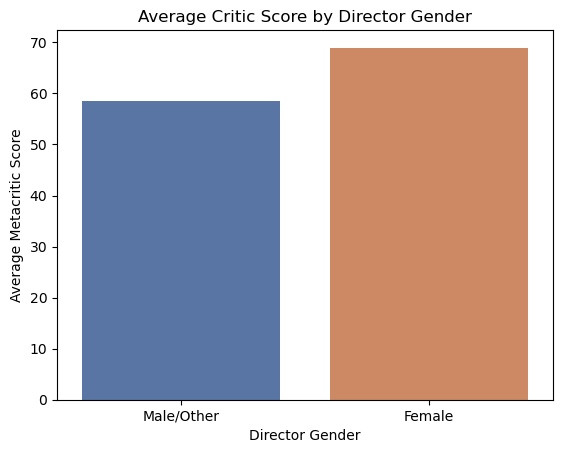

In [16]:
avg_scores = (
    movies.groupby("female_director")["score"]
    .mean()
    .reset_index()
)

# Replace True/False with friendly labels
avg_scores["director_gender"] = avg_scores["female_director"].map({
    False: "Male/Other",
    True: "Female"
})

sns.barplot(
    data=avg_scores,
    x="director_gender",
    y="score",
    hue="director_gender",      # allows custom colors
    palette={
        "Male/Other": "#4C72B0",  # default seaborn blue
        "Female": "#DD8452"       # same orange often used by seaborn
    },
    legend=False
)

plt.xlabel("Director Gender")
plt.ylabel("Average Metacritic Score")
plt.title("Average Critic Score by Director Gender")

plt.show()

# Visualization 2: Budget vs Gross Revenue

This scatterplot shows the relationship between movie budgets and gross revenue.

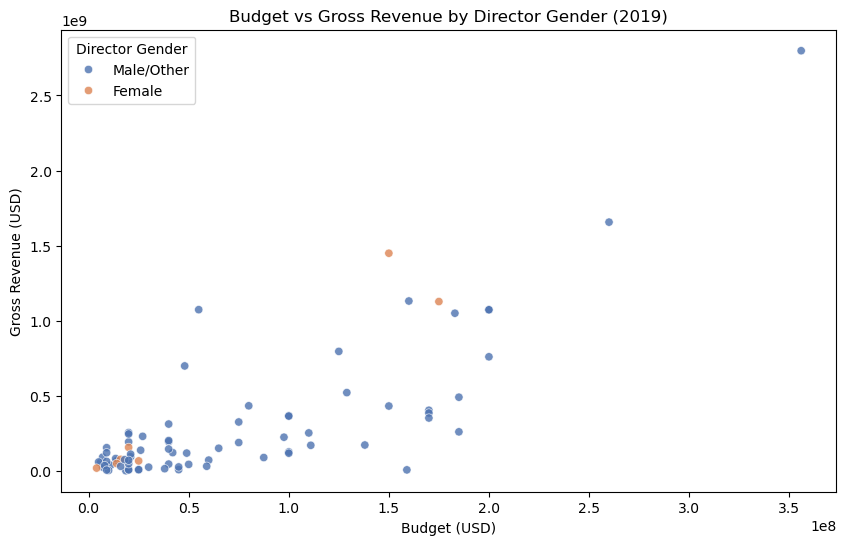

In [17]:
plt.figure(figsize=(10,6))

movies["director_gender"] = movies["female_director"].map({
    False: "Male/Other",
    True: "Female"
})

sns.scatterplot(
    data=movies,
    x="budget_usd",
    y="gross_sales_usd",
    hue="director_gender",
    palette={
        "Male/Other": "#4C72B0",  # blue
        "Female": "#DD8452"       # orange
    },
    alpha=0.8
)

plt.xlabel("Budget (USD)")
plt.ylabel("Gross Revenue (USD)")
plt.title("Budget vs Gross Revenue by Director Gender (2019)")

plt.legend(
    title="Director Gender"
)

plt.show()

# Additional Exploration: 2015–2020

### Metacritic Average Scores and ROI

After completing the primary 2019 analysis, the dataset was expanded to include films released between 2015 and 2020.

This additional analysis was performed to determine whether the observed patterns were unique to 2019 or reflected broader industry trends.

In [18]:
# Retrieve IMDB data for movies released in 2015-2020 and convert to DataFrame

imdb_2015_2020 = pd.DataFrame(
    list(
        db["IMDB_Pipeline_View"].find(
            {
                "release_year": {
                    "$gte": 2015,
                    "$lte": 2020
                }
            }
        )
    )
)

# Retrieve Metacritic data for movies released in 2015-2020 and convert to DataFrame
metacritic_2015_2020 = metacritic[
    (metacritic["year"] >= 2015) &
    (metacritic["year"] <= 2020)
]

# Merge the two imdb and metacritic data on the title column for movies released in 2015-2020
movies_2015_2020 = pd.merge(
    imdb_2015_2020,
    metacritic_2015_2020,
    how="inner",
    on="title"
)

print(movies_2015_2020.head())

                      _id_x                    budget  \
0  637fd8aaa23f8f7c1aca9f04   $40,000,000 (estimated)   
1  637fd8aca23f8f7c1aca9f05    $3,500,000 (estimated)   
2  637fd8afa23f8f7c1aca9f06    $3,000,000 (estimated)   
3  637fd8b2a23f8f7c1aca9f07  $150,000,000 (estimated)   
4  637fd8b5a23f8f7c1aca9f08   $28,000,000 (estimated)   

                                                cast  \
0  Dakota Johnson, Jamie Dornan, Jennifer Ehle, E...   
1  Anya Taylor-Joy, Ralph Ineson, Kate Dickie, Ha...   
2  Aomi Muyock, Karl Glusman, Klara Kristin, Ugo ...   
3  Tom Hardy, Charlize Theron, Nicholas Hoult, Hu...   
4  Ryan Gosling, Rudy Eisenzopf, Casey Groves, Ch...   

                                 certification  \
0  TV-14::(DLS), TV-MA::(S), TV-14, R, Unrated   
1                                            R   
2                      TV-MA::(Netflix rating)   
3                  TV-14::(DLV, TV Rating.), R   
4                                            R   

                   

In [19]:
# Classify female directors in movies dataset for movies released in 2015-2020
movies_2015_2020["female_director"] = (
    movies_2015_2020["director"]
    .apply(
        lambda x: any(
            d in str(x)
            for d in female_list["director"]
        )
    )
)

# Calculate ROI for movies released in 2015-2020
movies_2015_2020["roi"] = (
    movies_2015_2020["gross_sales_usd"]
    / movies_2015_2020["budget_usd"]
)

# Calculate and print the percentage of movies classified as female-directed
female_count = movies_2015_2020["female_director"].sum()
total_count = len(movies_2015_2020)

print(
    f"{female_count} of {total_count} movies "
    f"({female_count/total_count:.1%}) "
    f"were classified as female-directed from 2015-2020."
)

# Display the first 10 movies classified as female-directed
movies_2015_2020[
    movies_2015_2020["female_director"]
][
    ["title", "director"]
].head(10)

210 of 2749 movies (7.6%) were classified as female-directed from 2015-2020.


,title,director
35,Pitch Perfect 2,Elizabeth Banks
40,The Intern,Nancy Meyers
55,The Invitation,Karyn Kusama
94,The Dressmaker,Jocelyn Moorhouse
112,Into the Forest,Patricia Rozema
119,Sleeping with Other People,Leslye Headland
137,Suffragette,Sarah Gavron
138,The Diary of a Teenage Girl,Marielle Heller
143,By the Sea,Angelina Jolie
150,Mississippi Grind,"Anna Boden, Ryan Fleck"


By expanding the dataset from 2015 to 2020 movies, we see the Return on Investment evens out.

In [20]:
# Group by female_director and calculate median values for user_rating_num, score, budget_usd, and roi for movies released in 2015-2020

movies_2015_2020.groupby("female_director").agg({
    "user_rating_num":"median",
    "score":"median",
    "budget_usd":"median",
    "gross_sales_usd":"median",
    "roi":"median"
})

,user_rating_num,score,budget_usd,gross_sales_usd,roi
female_director,,,,,
False,6.4,62.0,21000000.0,91244913.0,3.062988
True,6.5,67.0,15500000.0,42898313.0,2.925436


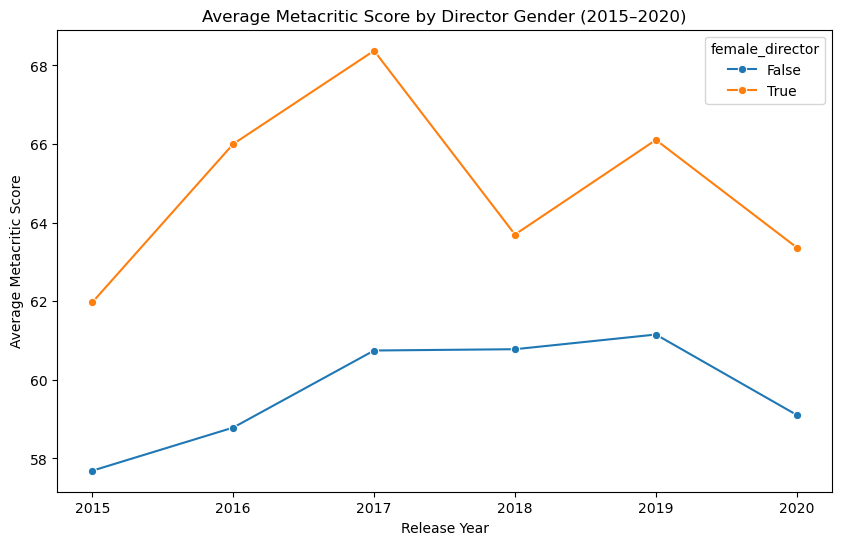

In [21]:
# Analyze trends in average critic scores over time for movies released from 2015 to 2020, comparing female-directed vs male/other-directed movies

yearly_scores = (
    movies_2015_2020
    .groupby(
        ["release_year", "female_director"]
    )["score"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(10,6))

sns.lineplot(
    data=yearly_scores,
    x="release_year",
    y="score",
    hue="female_director",
    marker="o"
)

plt.xlabel("Release Year")
plt.ylabel("Average Metacritic Score")
plt.title(
    "Average Metacritic Score by Director Gender (2015–2020)"
)

plt.show()

### Exploring Average Metacritic Score, Also by Genre

This was an idea brought in by Selamawit Gebnanaw, a fellow DATA320 student, who asked if I had enough data to break up the average Metacritic score by genre. I figured since I was most of the way there already, it would not take much time or effort to add in those genre categories. In the end, I think provides support for the broader Metacritic score differences and conclusions later.

In [22]:
# Display a sample of the genres column for movies released in 2015-2020 to understand its structure and content

movies_2015_2020["genres"].sample(10)

2080            Action, Adventure, Comedy, Sci-Fi
1750                    Biography, Drama, History
210                      Action, Sci-Fi, Thriller
921                                  Drama, Sport
29                        Drama, Fantasy, Romance
1184               Biography, Drama, History, War
155     Drama, Fantasy, Horror, Musical, Thriller
1810                               Drama, Romance
1461                                Comedy, Drama
1134                               Drama, Romance
Name: genres, dtype: object

In [23]:
# The genres column contains comma-separated lists of genres for each movie. To analyze the distribution of genres,
# we need to split these lists into individual rows.

genre_movies = movies_2015_2020.copy()

genre_movies["genres"] = (
    genre_movies["genres"]
    .fillna("")
    .str.split(",")
)

genre_movies = genre_movies.explode("genres")

genre_movies["genres"] = (
    genre_movies["genres"]
    .str.strip()
)

print(genre_movies[["title", "genres"]].head(10))

                  title    genres
0  Fifty Shades of Grey     Drama
0  Fifty Shades of Grey   Romance
0  Fifty Shades of Grey  Thriller
1             The Witch     Drama
1             The Witch   Fantasy
1             The Witch    Horror
1             The Witch   Mystery
1             The Witch  Thriller
2                  Love     Drama
2                  Love   Romance


In [24]:
# Now we can analyze the average critic scores by genre and female director status for movies released in 2015-2020

genre_scores = (
    genre_movies
    .groupby(
        ["genres", "female_director"]
    )["score"]
    .mean()
    .reset_index()
)

print(genre_scores.head(20))

         genres  female_director      score
0        Action            False  52.080092
1        Action             True  55.055556
2     Adventure            False  56.714706
3     Adventure             True  58.684211
4     Animation            False  62.101852
5     Animation             True  65.000000
6     Biography            False  63.984375
7     Biography             True  66.096774
8        Comedy            False  56.880721
9        Comedy             True  64.522388
10        Crime            False  57.309463
11        Crime             True  60.380952
12  Documentary            False  73.210117
13  Documentary             True  76.375000
14        Drama            False  61.633856
15        Drama             True  65.244048
16       Family            False  56.500000
17       Family             True  53.727273
18      Fantasy            False  57.857708
19      Fantasy             True  56.333333


In [25]:
# To ensure we have enough data for each genre, we can also calculate the count of movies in each genre
# then filter out genres with too few movies.

genre_counts = (
    genre_movies
    .groupby(
        ["genres", "female_director"]
    )
    .size()
    .reset_index(name="count")
)

genre_scores = genre_scores.merge(
    genre_counts,
    on=["genres", "female_director"]
)

genre_counts = (
    genre_movies
    .groupby(
        ["genres", "female_director"]
    )
    .size()
    .reset_index(name="genre_count")
)

genre_scores = genre_scores.merge(
    genre_counts,
    on=["genres", "female_director"],
    how="left"
)

genre_scores = genre_scores[
    genre_scores["genre_count"] >= 5
]

print(genre_scores.head(20))

         genres  female_director      score  count  genre_count
0        Action            False  52.080092    437          437
1        Action             True  55.055556     18           18
2     Adventure            False  56.714706    340          340
3     Adventure             True  58.684211     19           19
4     Animation            False  62.101852    108          108
6     Biography            False  63.984375    320          320
7     Biography             True  66.096774     31           31
8        Comedy            False  56.880721    721          721
9        Comedy             True  64.522388     67           67
10        Crime            False  57.309463    391          391
11        Crime             True  60.380952     21           21
12  Documentary            False  73.210117    257          257
13  Documentary             True  76.375000     16           16
14        Drama            False  61.633856   1595         1595
15        Drama             True  65.244

In [26]:
# For better visualization, we can also create a new column that combines the female_director boolean
# with the genre to create a more descriptive label for plotting.

genre_movies["director_gender"] = (
    genre_movies["female_director"]
    .map({
        False: "Male/Other",
        True: "Female"
    })
)

In [27]:
# Now we can calculate the average scores by genre and director gender and thencalculate the difference
# in average scores between female-directed and male/other-directed movies for each genre.
# Removing genres that are less relevant for this analysis (e.g., News, Music) to focus on more traditional movie genres
# where we have more data and clearer comparisons. This also helps to avoid skewing the results with genres that may
# have very different dynamics or fewer movies overall.

excluded_genres = ["News", "Music"]

genre_movies_filtered = genre_movies[
    ~genre_movies["genres"].isin(excluded_genres)
].copy()

genre_diff = (
    genre_movies_filtered
    .groupby(
        ["genres", "director_gender"]
    )["score"]
    .mean()
    .unstack()
)

genre_diff["difference"] = (
    genre_diff["Female"]
    - genre_diff["Male/Other"]
)

genre_diff = (
    genre_diff
    .sort_values(
        "difference",
        ascending=False
    )
    .reset_index()
)

print(genre_diff)

director_gender       genres     Female  Male/Other  difference
0                    Western  71.666667   59.270270   12.396396
1                      Sport  73.000000   63.109091    9.890909
2                        War  69.300000   60.553719    8.746281
3                   Thriller  63.029412   54.636364    8.393048
4                     Horror  63.388889   55.448571    7.940317
5                     Comedy  64.522388   56.880721    7.641667
6                    History  69.714286   62.747253    6.967033
7                    Musical  64.000000   57.439024    6.560976
8                    Mystery  63.250000   57.435821    5.814179
9                     Sci-Fi  60.100000   55.219512    4.880488
10                   Romance  62.568627   58.327128    4.241500
11                     Drama  65.244048   61.633856    3.610192
12               Documentary  76.375000   73.210117    3.164883
13                     Crime  60.380952   57.309463    3.071489
14                    Action  55.055556 

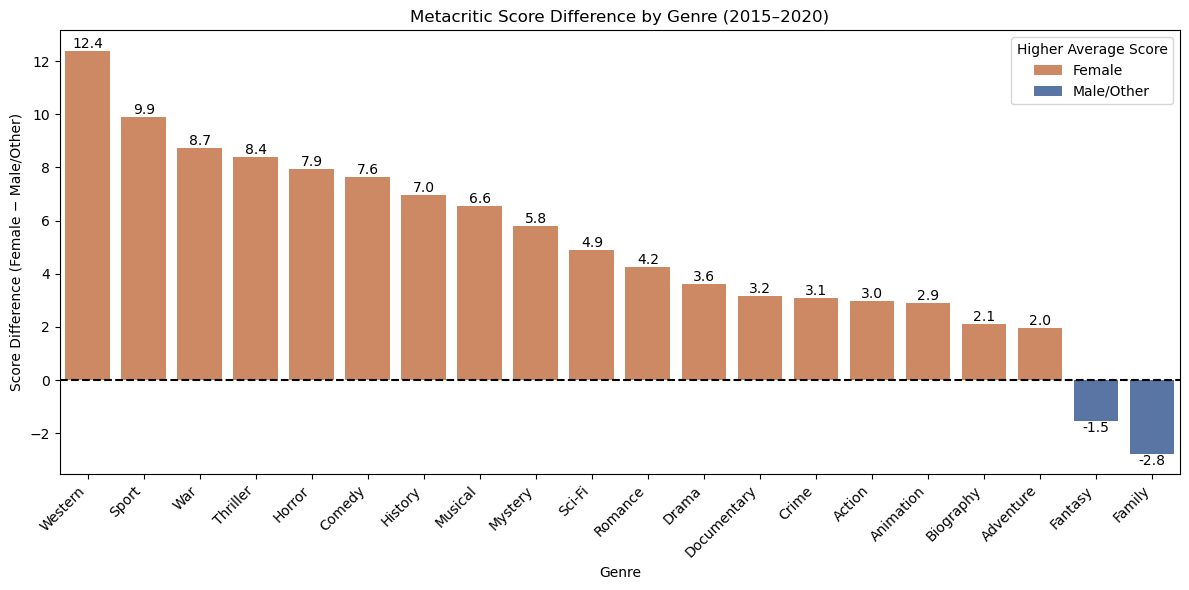

In [ ]:
# Visualize the score differences by genre using a bar plot, coloring bars based on whether female-directed movies had higher average scores

plt.figure(figsize=(12,6))

genre_diff["higher_score_for"] = genre_diff.apply(
    lambda row: "Female" if row["Female"] > row["Male/Other"] else "Male/Other",
    axis=1
)

ax = sns.barplot(
    data=genre_diff,
    x="genres",
    y="difference",
    hue="higher_score_for",
    dodge=False,
    palette={
        "Female": "#DD8452",
        "Male/Other": "#4C72B0"
    }
)

plt.axhline(
    y=0,
    color="black",
    linestyle="--"
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f"
    )

plt.xlabel("Genre")
plt.ylabel(
    "Score Difference (Female − Male/Other)"
)

plt.title(
    "Metacritic Score Difference by Genre (2015–2020)"
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.legend(
    title="Higher Average Score"
)

plt.tight_layout()
plt.show()

## Conclusions

This project examined differences between female-directed and male/other-directed films released in 2019 using data from IMDB and Metacritic. The datasets were merged and analyzed using descriptive statistics, machine learning sentiment analysis, and regression modeling.

The results showed that female-directed films received substantially higher critic scores than male/other-directed films. Audience ratings were generally similar between the two groups, while female-directed films tended to be produced with smaller budgets. In the 2019 dataset, female-directed films also demonstrated a higher average return on investment.

Regression analysis confirmed that director gender was significantly associated with critic scores. Female-directed films scored approximately 10 points higher on Metacritic on average. Sentiment analysis of movie descriptions did not significantly improve the model, suggesting that plot description sentiment was not a strong predictor of critic reception. The sentiment model appeared to capture the tone of movie descriptions rather than the quality or reception of the films themselves.

As an additional validation step, the analysis was expanded to include films released between 2015 and 2020. The broader dataset showed that higher critic scores and smaller budgets for female-directed films remained consistent across multiple years, while the ROI advantage observed in 2019 was less consistent. This suggests that 2019 may have been an especially strong year for female-directed films rather than evidence of a long-term profitability advantage.

A genre-level analysis provided additional context for these findings. When films released between 2015 and 2020 were grouped by genre, female-directed films received higher average Metacritic scores in 20 of 22 genres. Higher scores were observed not only in dramas and documentaries, but also in genres traditionally associated with male directors, including action, crime, science fiction, horror, and war films. Only the fantasy and family genres showed a small advantage for male/other-directed films. This suggests that the higher critic scores associated with female-directed films were not driven by a single genre, but were broadly distributed across many types of films.

While this analysis does not establish a causal relationship between director gender and film quality, it does suggest that female-directed films consistently achieved strong critical reception across a wide range of genres despite generally having smaller production budgets.

Overall, this project demonstrates how combining multiple data sources, machine learning techniques, statistical modeling, and data visualization can be used to explore patterns in movie performance and critical reception.